In [4]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import re

In [9]:
# # reading in ERA5 u, v, w and q

# base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

# years = [str(year) for year in range(2001, 2019)]

# def get_files(folder, component):

#     files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

#     filtered_files = [f for f in files if any(year in f for year in years)]
    
#     return filtered_files

# # Get the files for each component

# u_files = get_files('u_component_of_wind', 'u_component_of_wind')

# v_files = get_files('v_component_of_wind', 'v_component_of_wind')

# w_files = get_files('vertical_velocity', 'vertical_velocity')

# q_files = get_files('specific_humidity', 'specific_humidity')

# all_files = u_files + v_files + q_files + w_files

# # open all datasets at once

# uvwq = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

In [10]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f) * 100
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

In [4]:
# removes underground values, contains advections and mean wind profiles

with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [5]:
# filtering for correct domain and time

uvwq = uvwq.sel(
    
    latitude=slice(40, 29),
    
    longitude=slice(-106, -94)
)

uvwq['time'] = uvwq['time'] - pd.Timedelta(hours=6)

uvwq = uvwq.where(
    
    (uvwq.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (uvwq.time.dt.year.isin(range(2001, 2019))),
    
    drop=True
)

In [6]:
_0lst = uvwq.sel(time=uvwq.time.dt.hour == 0)

_3lst = uvwq.sel(time=uvwq.time.dt.hour == 3)

_6lst = uvwq.sel(time=uvwq.time.dt.hour == 6)

_9lst = uvwq.sel(time=uvwq.time.dt.hour == 9)

_12lst = uvwq.sel(time=uvwq.time.dt.hour == 12)

_15lst = uvwq.sel(time=uvwq.time.dt.hour == 15)

_18lst = uvwq.sel(time=uvwq.time.dt.hour == 18)

_21lst = uvwq.sel(time=uvwq.time.dt.hour == 21)

In [7]:
def calculate_vertical_advection(w, q, pressure, lat, lon):
    """
    Calculate vertical advection of specific humidity over a domain without flipping the pressure array.
    
    Args:
        w (ndarray): Vertical velocity (Pa/s), shape = (levels, lat, lon).
        q (ndarray): Specific humidity (kg/kg), shape = (levels, lat, lon).
        pressure (ndarray): Pressure levels (Pa), shape = (levels,).
        lat (ndarray): Latitude values (degrees), shape = (lat,).
        lon (ndarray): Longitude values (degrees), shape = (lon,).
    
    Returns:
        vertical_advection_area_weighted (ndarray): Area-weighted vertical advection (10^3/day),
                                                    shape = (levels,).
    """
    
    R = 6371000  # radius of Earth (meters)
    
    rho_water = 1000  # kg/m^3
    
    seconds_to_day = 60 * 60 * 24  # to convert from s --> day

    # Grid spacing and corrections
    delta_y = np.radians(lat[1]) - np.radians(lat[0])
    
    delta_x = np.radians(lon[1]) - np.radians(lon[0])
    
    lon_grid, lat_grid = np.meshgrid(np.radians(lon), np.radians(lat))
    
    cos_correction = np.cos(lat_grid)

    dx = R * cos_correction * delta_x  # Zonal grid spacing in meters
    
    dy = R * delta_y                   # Meridional grid spacing in meters
    
    grid_area = dx * dy                # Area of each grid cell (lat, lon)
    
    total_area = np.sum(grid_area)     # Total domain area
        
    # Initialize the vertical gradient array
    dqdp = np.zeros_like(q)

    # Compute vertical gradient of specific humidity (dq/dp)
    for j in range(1, q.shape[0] - 1):  # Central differencing for interior levels
        
        dqdp[j, :, :] = (q[j - 1, :, :] - q[j + 1, :, :]) / (pressure[j - 1] - pressure[j + 1])

    # Forward/backward differencing for boundaries
    dqdp[0, :, :] = (q[0, :, :] - q[1, :, :]) / (pressure[0] - pressure[1])
    
    dqdp[-1, :, :] = (q[-2, :, :] - q[-1, :, :]) / (pressure[-2] - pressure[-1])

    # Vertical advection term: -omega * dq/dp
    vertical_advection = -(w * dqdp)  # Shape = (levels, lat, lon)
    
    # Area-weighted average across the domain for each pressure level
    vertical_advection_area_weighted = np.sum(vertical_advection * grid_area, axis=(1, 2)) / total_area

    # Convert to mm/day
    vertical_advection_area_weighted *= seconds_to_day * rho_water  

    return vertical_advection_area_weighted

In [8]:
# array = (time = 12 LST, levels, latitude, longitude)

# reversing latitude to be increasing, pressure should go top to bottom 

u = _0lst['u'].load().data[:, :, ::-1, :]

print("u loaded")

v = _0lst['v'].load().data[:, :, ::-1, :]

print("v loaded")

q = _0lst['q'].load().data[:, :, ::-1, :] 

print("q loaded")

w = _0lst['w'].load().data[:, :, ::-1, :] 

print("w loaded")

latitude = _0lst['latitude'].data[::-1]

longitude = _0lst['longitude'].data

pressure = _0lst['level'].data * 100 # pressure needs to be Pa for advection calculation

u loaded
v loaded
q loaded
w loaded


In [ ]:
# Ensure columns exist in master for storing advection profiles

master['0lst_vertical_advection'] = None

for date in range(master.shape[0]):
        
    target_date = master['date'].iloc[date]  

    target_date = np.datetime64(target_date, 'D')

    # Find the index in _0lst['time'].data

    date_idx = np.where(_0lst['time'].data.astype('datetime64[D]') == target_date)[0][0]

    lat_idx = master['latitude'].iloc[date]
    
    lon_idx = master['longitude'].iloc[date]

    # Define the center point and half-window (in degrees)
    
    delta = 0.5
    
    lat_mask = (latitude >= (lat_idx - delta)) & (latitude <= (lat_idx + delta))
    
    lon_mask = (longitude >= (lon_idx - delta)) & (longitude <= (lon_idx + delta))

    lat_indices = np.where(lat_mask)[0]
    
    lon_indices = np.where(lon_mask)[0]

    lat_mini = latitude[lat_indices]
    
    lon_mini = longitude[lon_indices]

    # Extract mini domains for u, v, q, w
    
    u_mini = u[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    v_mini = v[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    q_mini = q[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]
    
    w_mini = w[date_idx, :, :, :][:, lat_mask, :][:, :, lon_mask]

    # Compute advection
        
    vertical_adv = calculate_vertical_advection(w_mini, q_mini, pressure, lat_mini, lon_mini)

    # Assign results to the DataFrame
    
    master.at[date, '0lst_vertical_advection'] = vertical_adv


In [12]:
dryapes = master[master['dryape']==True]

wetapes = master[master['wetape']==True]

dry_vertical = np.stack(dryapes['0lst_vertical_advection'].values)  # Shape (num_rows, array_length)

dry_mean = dry_vertical.mean(axis=0)  # Average across rows

wet_vertical = np.stack(wetapes['0lst_vertical_advection'].values)  # Shape (num_rows, array_length)

wet_mean = wet_vertical.mean(axis=0)  # Average across rows

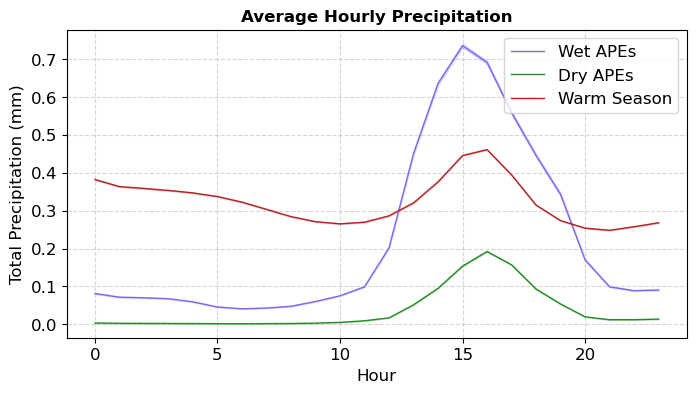

In [35]:
wet_precip_array = np.stack(wetapes["daily_precip"].dropna().values)

dry_precip_array = np.stack(dryapes["daily_precip"].dropna().values)

# Filter master to only include days where daily_precip > 0.1 mm
filtered_master = master.loc[master["daily_precip"].apply(lambda x: np.sum(x) > 1)]

all_days_precip_array = np.stack(filtered_master["daily_precip"].dropna().values)

# Compute mean precipitation
mean_wet_precip = np.mean(wet_precip_array, axis=0)
mean_dry_precip = np.mean(dry_precip_array, axis=0)
mean_all_days_precip = np.mean(all_days_precip_array, axis=0)

# Compute Standard Error (SE)
se_wet_precip = np.std(wet_precip_array, axis=0)  / np.sqrt(wet_precip_array.shape[0])
se_dry_precip = np.std(dry_precip_array, axis=0) / np.sqrt(dry_precip_array.shape[0])
se_all_precip = np.std(all_days_precip_array, axis=0) / np.sqrt(all_days_precip_array.shape[0])

# Define x-axis (0 to 23 hours)
hours = np.arange(0, 24)

# Create figure
plt.figure(figsize=(8, 4))

# Plot wet case
plt.plot(hours, mean_wet_precip, label='Wet APEs', color='#7B68EE', linewidth=1)  # Medium purple
plt.fill_between(hours, mean_wet_precip - se_wet_precip, mean_wet_precip + se_wet_precip, 
                 color='#7B68EE', alpha=0.2)  # Light purple shading for SE

# Plot dry case
plt.plot(hours, mean_dry_precip, label='Dry APEs', color='#228B22', linewidth=1)  # Dark green
plt.fill_between(hours, mean_dry_precip - se_dry_precip, mean_dry_precip + se_dry_precip, 
                 color='#228B22', alpha=0.2)  # Light green shading for SE

# Plot warm season case
plt.plot(hours, mean_all_days_precip, label='Warm Season', color='#B22222', linewidth=1)  

plt.fill_between(hours, mean_all_days_precip - se_all_precip, mean_all_days_precip + se_all_precip, 
                 color='#B22222', alpha=0.2)  # Light red shading for SE

# Formatting
plt.xlabel('Hour', fontsize=12)

plt.ylabel('Total Precipitation (mm)', fontsize=12)

plt.title('Average Hourly Precipitation', fontsize=12, fontweight='bold')

plt.xticks(fontsize=12)

plt.yticks(fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.legend(fontsize=12, loc='upper right')

plt.show()


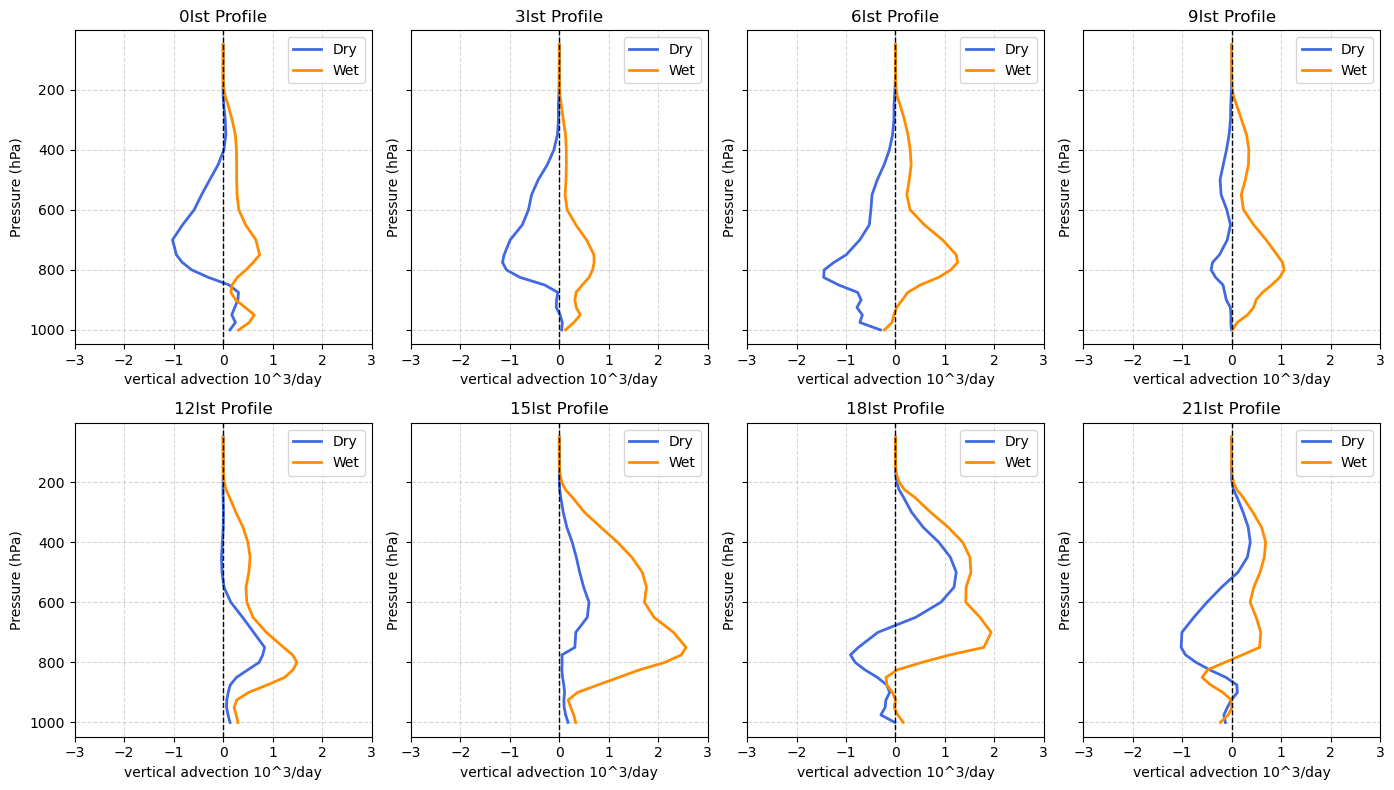

In [12]:
with open('/home/annierosen16/vertical_advection_profiles.pkl', 'rb') as f:
    
    vap = pickle.load(f)

def extract_numeric_hour(time_str):
    
    return int(re.findall(r'\d+', time_str)[0])  # Extract numeric part

# Extract unique times and sort numerically
unique_times = sorted(set(k.split('_')[0] for k in vap.keys()), key=extract_numeric_hour)

dry_color = "#4169E1"  # Royal Blue

wet_color = "#FF8C00"  # Dark Orange

# Define subplot configuration
n_times = len(unique_times)

n_cols = 4  # 4 columns

n_rows = 2  # 2 rows

plots_per_figure = n_rows * n_cols  # 8 plots per figure

# Loop through in batches of 8 (4x2 layout per figure)
for i in range(0, n_times, plots_per_figure):
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 8), sharey=True)
    
    axes = axes.flatten()  # Flatten for easy indexing
    
    for j, time in enumerate(unique_times[i:i + plots_per_figure]):
        
        dry_key = f"{time}_dry"
        
        wet_key = f"{time}_wet"
        
        if dry_key in vap and wet_key in vap:
            
            dry_profile = vap[dry_key]
            
            wet_profile = vap[wet_key]
            
            ax = axes[j]
            
            ax.plot(dry_profile, pressure / 100, label='Dry', color=dry_color, linewidth=2)
            
            ax.plot(wet_profile, pressure / 100, label='Wet', color=wet_color, linewidth=2)
            
            # Formatting
            
            ax.invert_yaxis()  # Invert to show pressure decreasing with height
            
            ax.set_xlabel('vertical advection 10^3/day')
            
            ax.set_ylabel('Pressure (hPa)')
            
            ax.set_title(f"{time} Profile", fontsize=12)
            
            ax.grid(True, linestyle="--", alpha=0.5)
            
            ax.legend()
            
            # Add zero line at x=0
            ax.axvline(0, linestyle='--', color='black', linewidth=1)

            # Set x-axis limits
            ax.set_xlim(-3, 3)
    
    # Remove unused subplots
    for k in range(j + 1, plots_per_figure):
        
        fig.delaxes(axes[k])

    # Adjust layout and show the figure
    
    plt.tight_layout()
    
    plt.gca().invert_yaxis()
    
    plt.show()
